# ICU Static Feature Engineering -- MIMIC-IV
> **Pipeline**: Mount -> Load -> Feature Engineering -> Validate -> Visualise -> Save  
> **Dataset**: MIMIC-IV v3.1 | **Output**: `icu_static_features.parquet`


## Step 1 -- Environment Setup & Paths

In [14]:
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

from google.colab import drive
drive.mount('/content/drive')

DATA_BASE = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Dataset/mimic_iv/mimic-iv-3.1')
OUT_BASE  = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
OUT_BASE.mkdir(parents=True, exist_ok=True)

# --- Plotting theme ---
PALETTE    = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED', '#0891B2']
DARK_BG    = '#0F172A'
CARD_BG    = '#1E293B'
TEXT_COLOR = '#F1F5F9'
GRID_COLOR = '#334155'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor':   CARD_BG,
    'axes.edgecolor':   GRID_COLOR,
    'axes.labelcolor':  TEXT_COLOR,
    'axes.titlecolor':  TEXT_COLOR,
    'xtick.color':      TEXT_COLOR,
    'ytick.color':      TEXT_COLOR,
    'text.color':       TEXT_COLOR,
    'grid.color':       GRID_COLOR,
    'grid.linewidth':   0.5,
    'axes.grid':        True,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
})

print('Environment ready.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready.


## Step 2 -- Load ICU Core Tables

In [15]:
# BUG FIX [1]: 'outtime' was loaded but never parsed to datetime.
# Added parse_dates so time-delta ops downstream work correctly.
icustays = pd.read_csv(
    DATA_BASE / 'icu/icustays.csv.gz',
    usecols=['stay_id', 'subject_id', 'hadm_id', 'intime', 'outtime'],
    parse_dates=['intime', 'outtime'],   # <-- outtime was missing
)

patients = pd.read_csv(
    DATA_BASE / 'hosp/patients.csv.gz',
    usecols=['subject_id', 'anchor_age', 'anchor_year', 'gender'],
)
patients['gender'] = patients['gender'].astype('category')

admissions = pd.read_csv(
    DATA_BASE / 'hosp/admissions.csv.gz',
    usecols=['hadm_id', 'admission_type'],
)

print(f'ICU stays  : {icustays.shape[0]:,}')
print(f'Patients   : {patients.shape[0]:,}')
print(f'Admissions : {admissions.shape[0]:,}')
icustays.head()


ICU stays  : 94,458
Patients   : 364,627
Admissions : 546,028


,subject_id,hadm_id,stay_id,intime,outtime
0,10000032,29079034,39553978,2180-07-23 14:00:00,2180-07-23 23:50:47
1,10000690,25860671,37081114,2150-11-02 19:37:00,2150-11-06 17:03:17
2,10000980,26913865,39765666,2189-06-27 08:42:00,2189-06-27 20:38:27
3,10001217,24597018,37067082,2157-11-20 19:18:02,2157-11-21 22:08:00
4,10001217,27703517,34592300,2157-12-19 15:42:24,2157-12-20 14:27:41


## Step 3 -- Build ICU Base Static Table

In [16]:
# BUG FIX [2]: Removed the dead-code defensive re-merge for 'outtime'.
# outtime is already in icustays and parse_dates handles it in Step 2.
icu_static = (
    icustays
    .merge(patients,   on='subject_id', how='left')
    .merge(admissions, on='hadm_id',    how='left')
)

missing_patients = icu_static['anchor_age'].isna().sum()
if missing_patients:
    print(f'WARNING: {missing_patients:,} stays have no patient record.')
else:
    print('All stays matched to a patient record.')

print(f'Merged shape: {icu_static.shape}')


All stays matched to a patient record.
Merged shape: (94458, 9)


## Step 4 -- Compute ICU Admission Age

In [17]:
# BUG FIX [3]: Intermediate 'icu_year' column was left in the final DataFrame.
# Prefixed with '_' and dropped immediately after use.
icu_static['_icu_year'] = icu_static['intime'].dt.year

icu_static['age_icu'] = (
    icu_static['anchor_age']
    + (icu_static['_icu_year'] - icu_static['anchor_year'])
).clip(lower=18, upper=89)  # MIMIC privacy rule

icu_static.drop(columns=['_icu_year'], inplace=True)

print('Age distribution (percentiles):')
print(icu_static['age_icu'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1))


Age distribution (percentiles):
count    94458.0
mean        64.7
std         16.5
min         18.0
5%          32.0
25%         55.0
50%         66.0
75%         77.0
95%         89.0
max         89.0
Name: age_icu, dtype: float64


## Step 5 -- Elective Admission Flag

In [18]:
# BUG FIX [4]: anchor_age, anchor_year, and admission_type retained unnecessarily.
# Dropping them immediately after derived columns are created.
icu_static['is_elective'] = (
    icu_static['admission_type']
    .str.contains('elective', case=False, na=False)
    .astype('int8')  # int8 vs int64 saves memory for a binary flag
)

icu_static.drop(columns=['admission_type', 'anchor_age', 'anchor_year'],
                inplace=True)

elective_pct = icu_static['is_elective'].mean() * 100
print(f'Elective admissions: {elective_pct:.1f}%'
      f' ({icu_static["is_elective"].sum():,} / {len(icu_static):,})')


Elective admissions: 3.2% (3,027 / 94,458)


## Step 6 -- Chronic Disease Flags

In [19]:
# BUG FIX [5]: Original chronic_flag() used row-wise .apply() -- slow on large DFs.
#              Replaced with vectorised str.startswith operations.
#
# BUG FIX [6]: chronic_flag_df used .size() then immediately overwrote with 1
#              -- pointless. Replaced with .drop_duplicates() which is correct.

CHRONIC_PREFIX_MAP = {
    'I50': 'CHF',
    'J44': 'COPD',
    'K72': 'LIVER',
    'K74': 'LIVER',
    'N18': 'RENAL',
    'D80': 'IMMUNO', 'D81': 'IMMUNO', 'D82': 'IMMUNO',
    'D83': 'IMMUNO', 'D84': 'IMMUNO',
}

def _vectorised_chronic(series: pd.Series) -> pd.Series:
    result = pd.Series(None, index=series.index, dtype=object)
    for prefix, label in CHRONIC_PREFIX_MAP.items():
        result[series.str.startswith(prefix, na=False)] = label
    # Cancer: any code starting with 'C' that has no other label
    result[series.str.startswith('C', na=False) & result.isna()] = 'CANCER'
    return result

diagnoses = pd.read_csv(
    DATA_BASE / 'hosp/diagnoses_icd.csv.gz',
    usecols=['hadm_id', 'icd_code'],
    dtype={'icd_code': str},
)

diagnoses['chronic_group'] = _vectorised_chronic(diagnoses['icd_code'])

chronic_hadm = (
    diagnoses
    .dropna(subset=['chronic_group'])
    [['hadm_id']]
    .drop_duplicates()
    .assign(has_chronic=1)
)

icu_static = icu_static.merge(chronic_hadm, on='hadm_id', how='left')
icu_static['has_chronic'] = icu_static['has_chronic'].fillna(0).astype('int8')

# For visualisation: per-condition prevalence
chronic_per_condition = (
    diagnoses
    .dropna(subset=['chronic_group'])
    .merge(icu_static[['hadm_id']], on='hadm_id', how='inner')
    [['hadm_id', 'chronic_group']]
    .drop_duplicates()
    .groupby('chronic_group')['hadm_id']
    .count()
    .sort_values(ascending=False)
)

chronic_pct = icu_static['has_chronic'].mean() * 100
print(f'Stays with >= 1 chronic condition: {chronic_pct:.1f}%')
print(chronic_per_condition.to_string())


Stays with >= 1 chronic condition: 29.5%
chronic_group
CHF       12110
RENAL      9769
CANCER     6571
COPD       5776
LIVER      3289
IMMUNO      518


## Step 7 -- Urine Output in First 24 Hours

In [20]:
# BUG FIX [7]: 'value' in outputevents.csv.gz is a STRING in MIMIC-IV.
#              The original code called .sum() on strings -- silent concatenation.
#              Fixed by reading as str then coercing to numeric.
# ENHANCEMENT: Added value > 0 filter and a physiological plausibility cap.

URINE_IDS     = {226559, 226560, 226561, 226562, 226563, 226584, 227488}
URINE_MAX_24H = 15_000  # mL -- physiological plausibility cap

intime_map = icu_static.set_index('stay_id')['intime']

urine_chunks = []
for chunk in pd.read_csv(
    DATA_BASE / 'icu/outputevents.csv.gz',
    usecols=['stay_id', 'itemid', 'charttime', 'value'],
    chunksize=2_000_000,
    dtype={'value': str},  # read as string first
):
    sub = chunk[chunk['itemid'].isin(URINE_IDS)].copy()
    if sub.empty:
        continue
    sub['value'] = pd.to_numeric(sub['value'], errors='coerce')  # then coerce
    sub = sub[sub['value'] > 0]  # drop zeros / negatives
    if not sub.empty:
        urine_chunks.append(sub)

if urine_chunks:
    urine = pd.concat(urine_chunks, ignore_index=True)
    urine['charttime'] = pd.to_datetime(urine['charttime'], errors='coerce')

    urine = urine.join(intime_map.rename('intime'), on='stay_id', how='inner')

    urine['hours_from_icu'] = (
        (urine['charttime'] - urine['intime']).dt.total_seconds() / 3600
    )

    urine_24h = (
        urine
        .loc[(urine['hours_from_icu'] >= 0) & (urine['hours_from_icu'] <= 24)]
        .groupby('stay_id')['value']
        .sum()
        .clip(upper=URINE_MAX_24H)
        .reset_index()
        .rename(columns={'value': 'urine_24h'})
    )
    print(f'Urine output computed for {len(urine_24h):,} stays.')
else:
    urine_24h = pd.DataFrame({'stay_id': icu_static['stay_id'], 'urine_24h': float('nan')})
    print('WARNING: No urine data found -- filled with NaN.')


Urine output computed for 88,042 stays.


## Step 8 -- Merge Urine & Final Column Selection

In [21]:
icu_static = icu_static.merge(urine_24h, on='stay_id', how='left')

FINAL_COLS = [
    'stay_id', 'subject_id', 'hadm_id',
    'intime', 'outtime',
    'age_icu', 'gender',
    'is_elective', 'has_chronic',
    'urine_24h',
]

icu_static = icu_static[FINAL_COLS].copy()

# Downcast for memory efficiency
icu_static['age_icu']   = icu_static['age_icu'].astype('int8')
icu_static['urine_24h'] = icu_static['urine_24h'].astype('float32')

print(f'Final shape  : {icu_static.shape}')
print(f'Memory usage : {icu_static.memory_usage(deep=True).sum() / 1e6:.1f} MB')
icu_static.dtypes


Final shape  : (94458, 10)
Memory usage : 4.5 MB


,0
stay_id,int64
subject_id,int64
hadm_id,int64
intime,datetime64[ns]
outtime,datetime64[ns]
age_icu,int8
gender,category
is_elective,int8
has_chronic,int8
urine_24h,float32


## Step 9 -- Data Validation

In [22]:
# BUG FIX [8]: assert age_icu.notna().all() would crash if anchor data is missing.
#              Replaced with informative checks that log issues without crashing.

issues = []

if icu_static['stay_id'].duplicated().sum():
    issues.append(f'Duplicate stay_ids: {icu_static["stay_id"].duplicated().sum():,}')

for col in ['stay_id', 'subject_id', 'hadm_id', 'intime', 'age_icu', 'gender']:
    n = icu_static[col].isna().sum()
    if n:
        issues.append(f'{col}: {n:,} nulls')

bad_age  = ((icu_static['age_icu'] < 18) | (icu_static['age_icu'] > 89)).sum()
if bad_age:
    issues.append(f'{bad_age:,} ages outside [18, 89]')

bad_time = (icu_static['outtime'] <= icu_static['intime']).sum()
if bad_time:
    issues.append(f'{bad_time:,} stays with outtime <= intime')

if issues:
    for msg in issues:
        print('WARNING:', msg)
else:
    print('All validation checks passed.')

print('\nMissing-value summary:')
print(icu_static.isna().sum().to_string())
icu_static.head()


All validation checks passed.

Missing-value summary:
stay_id           0
subject_id        0
hadm_id           0
intime            0
outtime          14
age_icu           0
gender            0
is_elective       0
has_chronic       0
urine_24h      6416


,stay_id,subject_id,hadm_id,intime,outtime,age_icu,gender,is_elective,has_chronic,urine_24h
0,39553978,10000032,29079034,2180-07-23 14:00:00,2180-07-23 23:50:47,52,F,0,0,175.0
1,37081114,10000690,25860671,2150-11-02 19:37:00,2150-11-06 17:03:17,86,F,0,0,695.0
2,39765666,10000980,26913865,2189-06-27 08:42:00,2189-06-27 20:38:27,76,F,0,0,3900.0
3,37067082,10001217,24597018,2157-11-20 19:18:02,2157-11-21 22:08:00,55,F,0,0,2645.0
4,34592300,10001217,27703517,2157-12-19 15:42:24,2157-12-20 14:27:41,55,F,0,0,2475.0


## Step 10 -- Enhanced Visualisation Dashboard

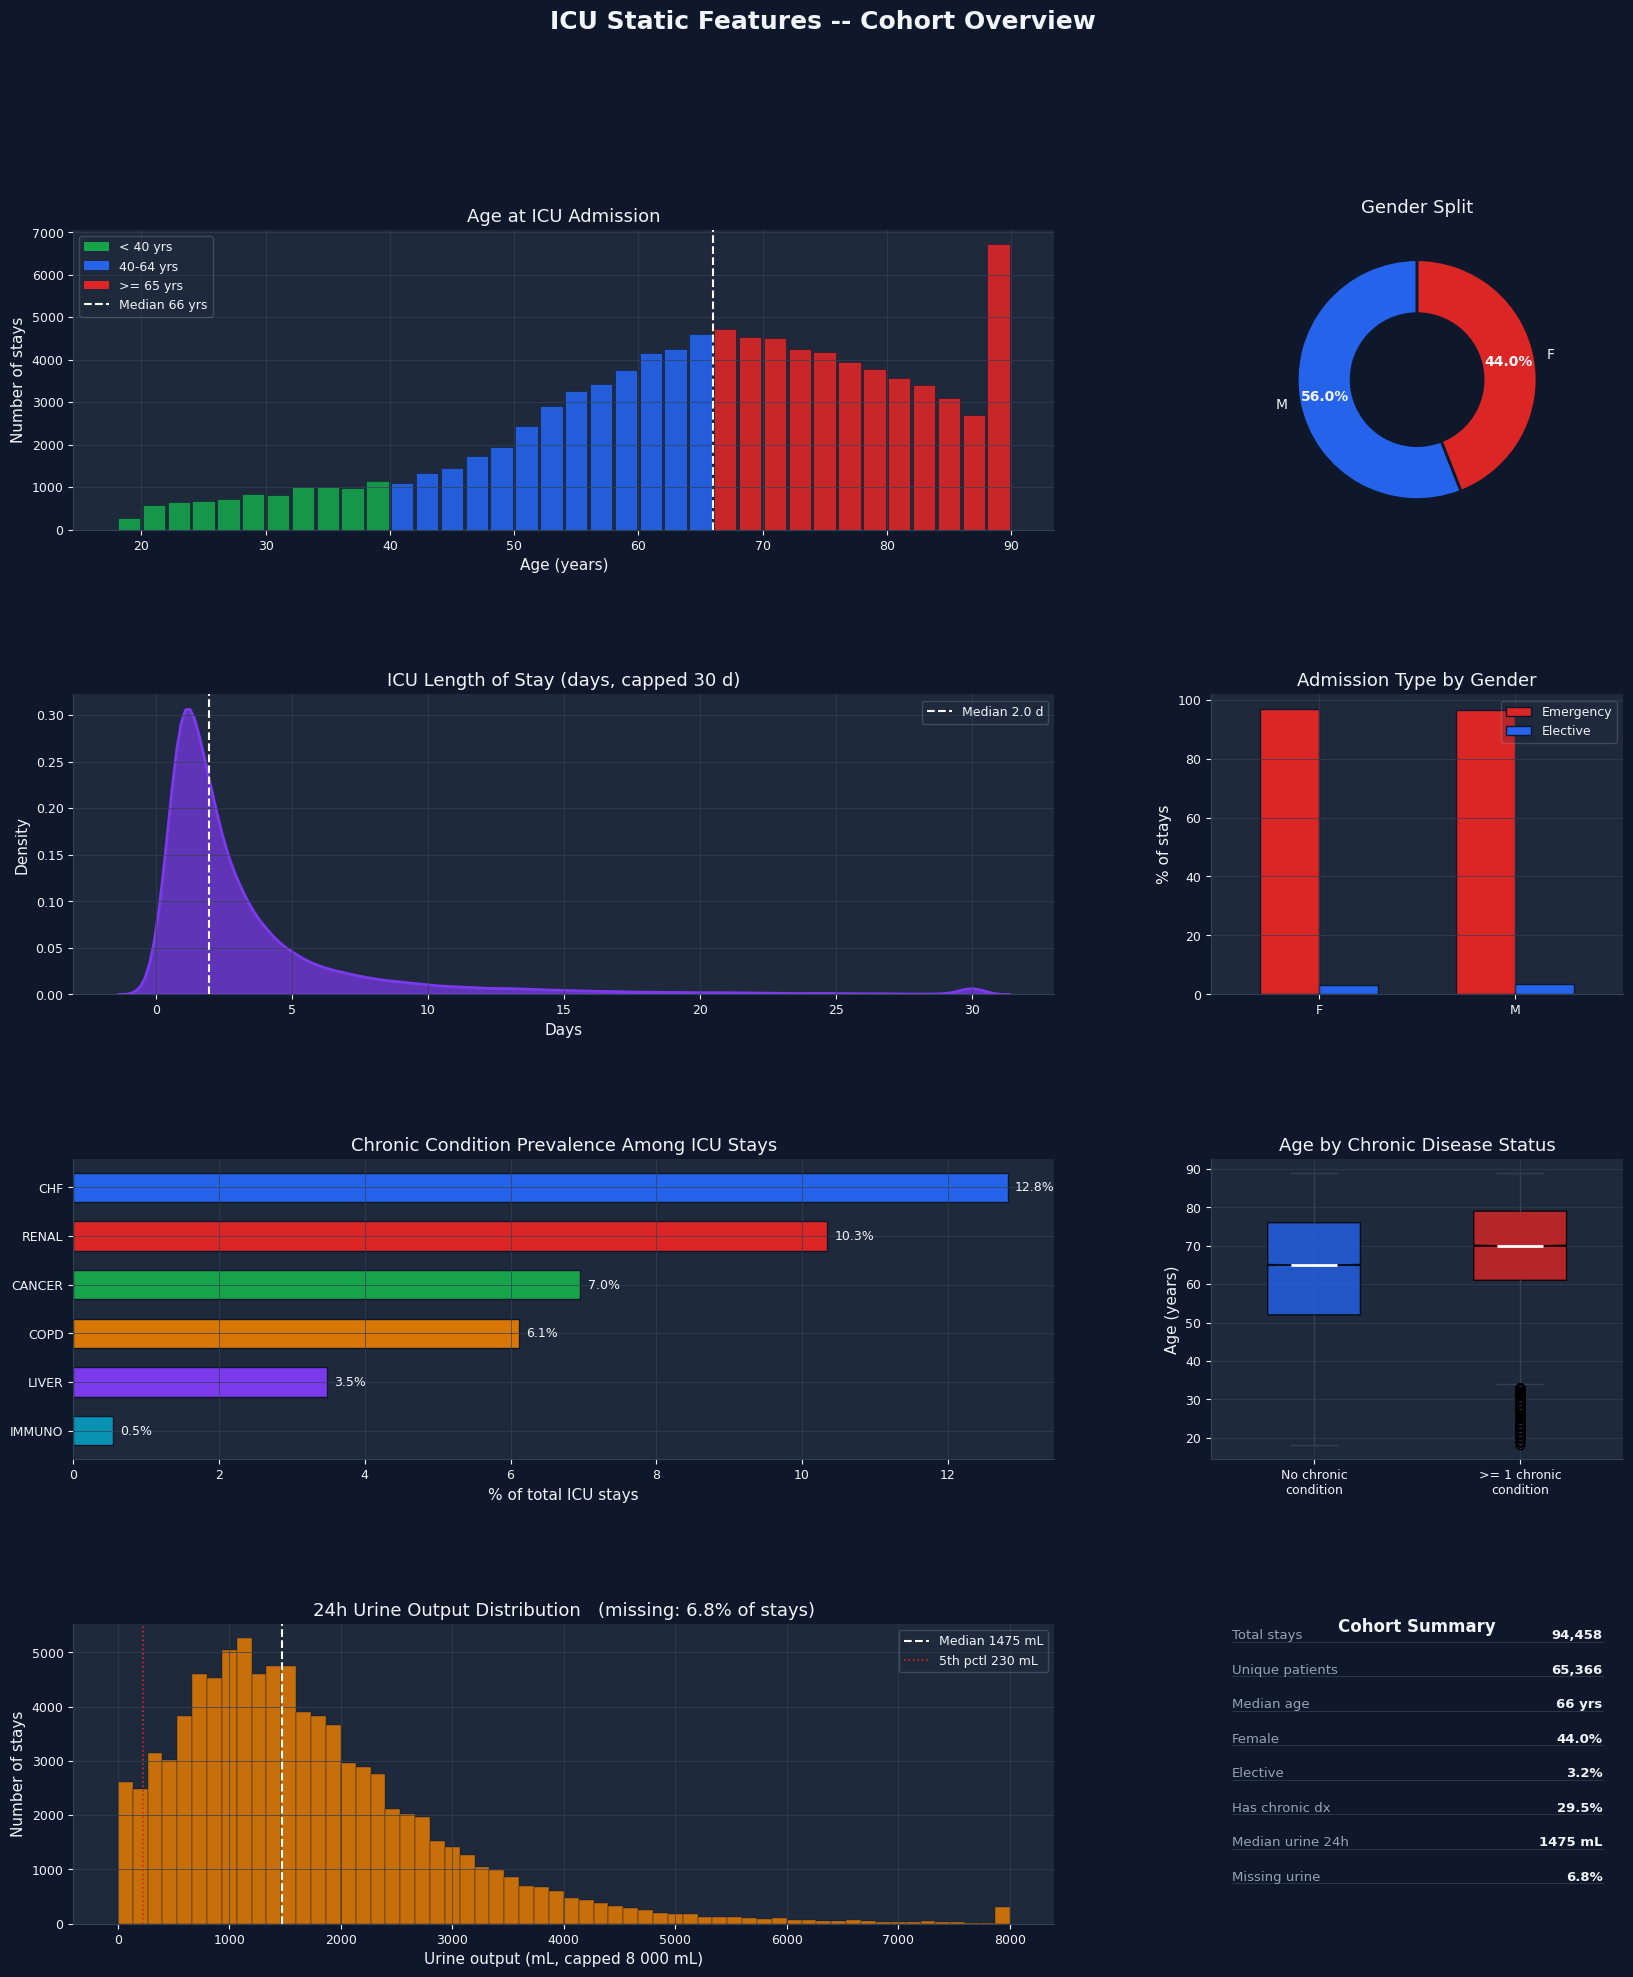

Dashboard saved.


In [23]:
def _spines_off(ax, sides=('top', 'right')):
    for s in sides:
        ax.spines[s].set_visible(False)


fig = plt.figure(figsize=(20, 22), facecolor=DARK_BG)
fig.suptitle('ICU Static Features -- Cohort Overview',
             fontsize=18, fontweight='bold', color=TEXT_COLOR, y=0.98)
gs = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38)


# 1. Age Distribution
ax1 = fig.add_subplot(gs[0, :2])
bins = range(18, 91, 2)
n, edges, patches = ax1.hist(
    icu_static['age_icu'].dropna(), bins=bins,
    color=PALETTE[0], edgecolor=DARK_BG, linewidth=0.4, alpha=0.9, rwidth=0.9,
)
for patch, left in zip(patches, edges):
    if   left < 40: patch.set_facecolor(PALETTE[2])
    elif left < 65: patch.set_facecolor(PALETTE[0])
    else:           patch.set_facecolor(PALETTE[1])
ax1.axvline(icu_static['age_icu'].median(), color='white', ls='--', lw=1.5,
            label=f"Median {icu_static['age_icu'].median():.0f} yrs")
ax1.set_title('Age at ICU Admission')
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Number of stays')
legend_handles = [
    mpatches.Patch(facecolor=PALETTE[2], label='< 40 yrs'),
    mpatches.Patch(facecolor=PALETTE[0], label='40-64 yrs'),
    mpatches.Patch(facecolor=PALETTE[1], label='>= 65 yrs'),
]
ax1.legend(handles=legend_handles + [ax1.get_lines()[0]], loc='upper left',
           framealpha=0.2, facecolor=CARD_BG)
_spines_off(ax1)


# 2. Gender Donut
ax2 = fig.add_subplot(gs[0, 2])
gender_counts = icu_static['gender'].value_counts()
wedge_props = dict(width=0.45, edgecolor=DARK_BG, linewidth=2)
wedges, texts, autotexts = ax2.pie(
    gender_counts, labels=gender_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=[PALETTE[0], PALETTE[1]],
    wedgeprops=wedge_props, pctdistance=0.78,
    textprops={'color': TEXT_COLOR, 'fontsize': 10},
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Gender Split', pad=12)


# 3. ICU Length-of-Stay KDE
ax3 = fig.add_subplot(gs[1, :2])
icu_static['los_hours'] = (
    (icu_static['outtime'] - icu_static['intime']).dt.total_seconds() / 3600
)
los_clipped = icu_static['los_hours'].clip(0, 30 * 24)
sns.kdeplot(los_clipped.dropna() / 24, ax=ax3, fill=True,
            color=PALETTE[4], alpha=0.7, linewidth=2)
ax3.axvline(los_clipped.median() / 24, color='white', ls='--', lw=1.5,
            label=f"Median {los_clipped.median()/24:.1f} d")
ax3.set_title('ICU Length of Stay (days, capped 30 d)')
ax3.set_xlabel('Days')
ax3.set_ylabel('Density')
ax3.legend(framealpha=0.2, facecolor=CARD_BG)
_spines_off(ax3)
icu_static.drop(columns=['los_hours'], inplace=True)


# 4. Elective vs Emergency by Gender
ax4 = fig.add_subplot(gs[1, 2])
ct = pd.crosstab(icu_static['gender'], icu_static['is_elective'], normalize='index') * 100
ct.columns = ['Emergency', 'Elective']
ct.plot(kind='bar', ax=ax4, color=[PALETTE[1], PALETTE[0]],
        edgecolor=DARK_BG, width=0.6)
ax4.set_title('Admission Type by Gender')
ax4.set_xlabel('')
ax4.set_ylabel('% of stays')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.legend(framealpha=0.2, facecolor=CARD_BG)
_spines_off(ax4)


# 5. Chronic Condition Prevalence
ax5 = fig.add_subplot(gs[2, :2])
cond_data = chronic_per_condition.reset_index()
cond_data.columns = ['Condition', 'Count']
cond_data['Prevalence (%)'] = cond_data['Count'] / len(icu_static) * 100
bars = ax5.barh(cond_data['Condition'], cond_data['Prevalence (%)'],
                color=PALETTE[:len(cond_data)], edgecolor=DARK_BG, height=0.6)
for bar, val in zip(bars, cond_data['Prevalence (%)']):
    ax5.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, color=TEXT_COLOR)
ax5.set_title('Chronic Condition Prevalence Among ICU Stays')
ax5.set_xlabel('% of total ICU stays')
ax5.invert_yaxis()
_spines_off(ax5)


# 6. Age by Chronic Disease Status (Box Plot)
ax6 = fig.add_subplot(gs[2, 2])
groups = [
    icu_static.loc[icu_static['has_chronic']==0, 'age_icu'].dropna(),
    icu_static.loc[icu_static['has_chronic']==1, 'age_icu'].dropna(),
]
bp = ax6.boxplot(groups, patch_artist=True, notch=True,
                 medianprops=dict(color='white', lw=2), widths=0.45)
for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for element in ('whiskers', 'caps', 'fliers'):
    for item in bp[element]:
        item.set(color=GRID_COLOR)
ax6.set_xticks([1, 2])
ax6.set_xticklabels(['No chronic\ncondition', '>= 1 chronic\ncondition'])
ax6.set_title('Age by Chronic Disease Status')
ax6.set_ylabel('Age (years)')
_spines_off(ax6)


# 7. Urine Output Distribution
ax7 = fig.add_subplot(gs[3, :2])
urine_valid = icu_static['urine_24h'].dropna()
urine_pct_missing = icu_static['urine_24h'].isna().mean() * 100
ax7.hist(urine_valid.clip(0, 8000), bins=60,
         color=PALETTE[3], edgecolor=DARK_BG, linewidth=0.3, alpha=0.9)
ax7.axvline(urine_valid.median(), color='white', ls='--', lw=1.5,
            label=f"Median {urine_valid.median():.0f} mL")
ax7.axvline(urine_valid.quantile(0.05), color=PALETTE[1], ls=':', lw=1.2,
            label=f"5th pctl {urine_valid.quantile(0.05):.0f} mL")
ax7.set_title(
    f'24h Urine Output Distribution   (missing: {urine_pct_missing:.1f}% of stays)'
)
ax7.set_xlabel('Urine output (mL, capped 8 000 mL)')
ax7.set_ylabel('Number of stays')
ax7.legend(framealpha=0.2, facecolor=CARD_BG)
_spines_off(ax7)


# 8. Cohort Summary Card
ax8 = fig.add_subplot(gs[3, 2])
ax8.axis('off')
stats = {
    'Total stays':       f"{len(icu_static):,}",
    'Unique patients':   f"{icu_static['subject_id'].nunique():,}",
    'Median age':        f"{icu_static['age_icu'].median():.0f} yrs",
    'Female':            f"{(icu_static['gender']=='F').mean()*100:.1f}%",
    'Elective':          f"{icu_static['is_elective'].mean()*100:.1f}%",
    'Has chronic dx':    f"{icu_static['has_chronic'].mean()*100:.1f}%",
    'Median urine 24h':  f"{icu_static['urine_24h'].median():.0f} mL",
    'Missing urine':     f"{icu_static['urine_24h'].isna().mean()*100:.1f}%",
}
y = 0.95
ax8.text(0.5, 1.02, 'Cohort Summary', ha='center', va='top',
         fontsize=12, fontweight='bold', color=TEXT_COLOR, transform=ax8.transAxes)
for label, value in stats.items():
    ax8.text(0.05, y, label, fontsize=9.5, color='#94A3B8', transform=ax8.transAxes)
    ax8.text(0.95, y, value, fontsize=9.5, fontweight='bold',
             color=TEXT_COLOR, ha='right', transform=ax8.transAxes)
    ax8.plot([0.05, 0.95], [y - 0.01, y - 0.01],
             color=GRID_COLOR, lw=0.5, clip_on=False,
             transform=ax8.transAxes)
    y -= 0.115


plt.savefig(
    '/content/drive/MyDrive/Multimodal_ICU_AIAssistant/icu_static_dashboard.png',
    dpi=180, bbox_inches='tight', facecolor=DARK_BG
)
plt.show()
print('Dashboard saved.')


## Step 11 -- Save Parquet

In [24]:
STATIC_PATH = OUT_BASE / 'icu_static_features.parquet'

icu_static.to_parquet(
    STATIC_PATH,
    index=False,
    engine='pyarrow',
    compression='snappy',
)

size_mb = STATIC_PATH.stat().st_size / 1e6
print(f'Saved -> {STATIC_PATH}')
print(f'File size  : {size_mb:.1f} MB')
print(f'Rows       : {len(icu_static):,}')
print(f'Columns    : {list(icu_static.columns)}')


Saved -> /content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet/icu_static_features.parquet
File size  : 4.0 MB
Rows       : 94,458
Columns    : ['stay_id', 'subject_id', 'hadm_id', 'intime', 'outtime', 'age_icu', 'gender', 'is_elective', 'has_chronic', 'urine_24h']
